# DSE 200 FINAL PROJECT
## Fall 2025
### Due Date: November 21th, 2025

This project is culmination of all you’ve learned in this course! You should expect to spend <b>24-32 total hours</b> on the project. Be sure to read all of the items below before starting.

There are a number of steps outlined below, but is critical that you do not view this as an entirely linear process.  Remember that the science component in data science is the creation of a hypothesis based on exploration and testing of that hypothesis through analysis.  You may need to go through many of these steps multiple times before you arrive at meaningful hypothesis or conclusions.

## Step 1: Find a dataset or datasets

Based on your interest, identify a dataset which you will want to examine.  You will find a starting point for where you can find open datasets at the end of this notebook, but feel free to use other datasets you have access to and can publicly share results about.


This step may take some time, as you’ll likely look at a number of datasets before you find one (or more) which holds promising data for the kinds of questions you want to ask. You are expected to use at least two interconnected datasets, e.g., two tables in one database or a combination of datasets which you can merge in some meaningful way.


In [722]:
#EXPLAIN AND INGEST YOUR DATASET IN THIS SECTION

Let's import what we'll need

In [723]:
!pip install backtesting

In [724]:
import kagglehub
import os
import pandas as pd
import numpy as np
import re
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.model_selection import train_test_split

Donwload what we need from kaggle

In [725]:

# Download latest version
path = kagglehub.dataset_download("mattiuzc/stock-exchange-data")

path2 = kagglehub.dataset_download("saketk511/world-important-events-ancient-to-modern")

print("Path to dataset files:", path)

#with open(path)

Using Colab cache for faster access to the 'stock-exchange-data' dataset.
Using Colab cache for faster access to the 'world-important-events-ancient-to-modern' dataset.
Path to dataset files: /kaggle/input/stock-exchange-data


In [726]:
os.listdir(path)
os.listdir(path2)

['World Important Dates.csv']

In [727]:
with open(os.path.join(path2, "World Important Dates.csv"), "r", encoding="utf-8") as f:
    for i in range(20):
        print(f.readline())


Sl. No,Name of Incident,Date,Month,Year,Country,Type of Event,Place Name,Impact,Affected Population,Important Person/Group Responsible,Outcome

1,Indus Valley Civilization Flourishes,Unknown,Unknown,2600 BC,India,Civilization,Indus Valley,Development of one of the world's earliest urban civilizations,Local inhabitants,Indus Valley people,Positive

2,Battle of the Ten Kings,Unknown,Unknown,1400 BC,India,Battle,Punjab,Rigvedic tribes consolidated their control over the region,Rigvedic tribes,Sudas,Positive

6,Establishment of the Delhi Sultanate,Unknown,Unknown,1206,India,Political,Delhi,Muslim rule established in parts of India,People of Delhi and surrounding regions,QutbUnknownudUnknowndin Aibak,Mixed

7,Battle of Panipat,21,April,1526,India,Battle,Panipat,Foundation of the Mughal Empire in India,Northern Indian kingdoms,Babur,Mixed

8,Establishment of British Raj,1,May,1858,India,Colonial,Whole India,Start of direct British governance in India,Indian subcontinent,British East India Co

Load the Data info dataframes

In [728]:
df_data = pd.read_csv(os.path.join(path, "indexData.csv"))
df_info = pd.read_csv(os.path.join(path, "indexInfo.csv"))
df_processed = pd.read_csv(os.path.join(path, "indexProcessed.csv"))
# df_events = pd.read_csv(os.path.join(path2, "World Important Dates.csv"))

df_events = pd.read_csv(
    os.path.join(path2, "World Important Dates.csv"),
    engine="python",
    quotechar='"',
    skipinitialspace=True
)
# df_events = pd.read_csv(
#     os.path.join(path2, "World Important Dates.csv"),
#     engine="python",
#     quotechar='"',
#     skipinitialspace=True,
#     on_bad_lines="skip"    # or "warn"
# )


## Step 2: Explore the datasets

In this step, you should explore what is present in the data and how the data is organized. You’ll need to determine what common features allow you to merge the datasets.  

You are expected to answer the following questions using the _pandas_ library and markdown cells to describe your actions:

* Are there quality issues in the dataset (noisy, missing data, etc.)?
* What will you need to do to clean and/or transform the raw data for analysis?

You are also expected to use the _matplotlib_ library to visually explore the datasets and explain your findings, specifically,

* How are the data distributed?
* What are some common trends?
* What are the relationships between variables in your datasets?

In [729]:
#PERFORM AND EXPLAIN YOUR EXPLORATORY ANALYSIS IN THIS SECTION

### Data overview
indexData.csv: daily price + volume data for major global indices

indexInfo.csv: metadata: region, exchange, currency, index name

indexProcessed.csv: cleaned version of the price data with USD-normalized closes (CloseUSD)

In [730]:

df_data.head()

,Index,Date,Open,High,Low,Close,Adj Close,Volume
0,NYA,1965-12-31,528.690002,528.690002,528.690002,528.690002,528.690002,0.0
1,NYA,1966-01-03,527.210022,527.210022,527.210022,527.210022,527.210022,0.0
2,NYA,1966-01-04,527.840027,527.840027,527.840027,527.840027,527.840027,0.0
3,NYA,1966-01-05,531.119995,531.119995,531.119995,531.119995,531.119995,0.0
4,NYA,1966-01-06,532.070007,532.070007,532.070007,532.070007,532.070007,0.0


In [731]:
df_info.head()

,Region,Exchange,Index,Currency
0,United States,New York Stock Exchange,NYA,USD
1,United States,NASDAQ,IXIC,USD
2,Hong Kong,Hong Kong Stock Exchange,HSI,HKD
3,China,Shanghai Stock Exchange,000001.SS,CNY
4,Japan,Tokyo Stock Exchange,N225,JPY


In [732]:
df_processed.head()

,Index,Date,Open,High,Low,Close,Adj Close,Volume,CloseUSD
0,HSI,1986-12-31,2568.300049,2568.300049,2568.300049,2568.300049,2568.300049,0.0,333.879006
1,HSI,1987-01-02,2540.100098,2540.100098,2540.100098,2540.100098,2540.100098,0.0,330.213013
2,HSI,1987-01-05,2552.399902,2552.399902,2552.399902,2552.399902,2552.399902,0.0,331.811987
3,HSI,1987-01-06,2583.899902,2583.899902,2583.899902,2583.899902,2583.899902,0.0,335.906987
4,HSI,1987-01-07,2607.100098,2607.100098,2607.100098,2607.100098,2607.100098,0.0,338.923013


In [733]:
df_events.head()

,Sl. No,Name of Incident,Date,Month,Year,Country,Type of Event,Place Name,Impact,Affected Population,Important Person/Group Responsible,Outcome
0,1,Indus Valley Civilization Flourishes,Unknown,Unknown,2600 BC,India,Civilization,Indus Valley,Development of one of the world's earliest urb...,Local inhabitants,Indus Valley people,Positive
1,2,Battle of the Ten Kings,Unknown,Unknown,1400 BC,India,Battle,Punjab,Rigvedic tribes consolidated their control ove...,Rigvedic tribes,Sudas,Positive
2,6,Establishment of the Delhi Sultanate,Unknown,Unknown,1206,India,Political,Delhi,Muslim rule established in parts of India,People of Delhi and surrounding regions,QutbUnknownudUnknowndin Aibak,Mixed
3,7,Battle of Panipat,21,April,1526,India,Battle,Panipat,Foundation of the Mughal Empire in India,Northern Indian kingdoms,Babur,Mixed
4,8,Establishment of British Raj,1,May,1858,India,Colonial,Whole India,Start of direct British governance in India,Indian subcontinent,British East India Company/Empire,Negative


### Explaination of data analysis
- Looking for data shape, content, & quality issues

### Check their shapes

In [734]:
df_data.shape, df_info.shape, df_processed.shape, df_events.shape

((112457, 8), (14, 4), (104224, 9), (1096, 12))

From the shape we can see that df_data and df_processed the majority of info and processed likely has fewer rows since it already been cleaned.

In [735]:
df_data.sample()

,Index,Date,Open,High,Low,Close,Adj Close,Volume
92090,J203.JO,2019-12-20,57558.92188,57756.75,57259.46094,57411.21094,57411.21094,0.0


### Check their column content

In [736]:
df_data.info(), df_info.info(), df_processed.info(), df_events.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112457 entries, 0 to 112456
Data columns (total 8 columns):
 #   Column     Non-Null Count   Dtype  
---  ------     --------------   -----  
 0   Index      112457 non-null  object 
 1   Date       112457 non-null  object 
 2   Open       110253 non-null  float64
 3   High       110253 non-null  float64
 4   Low        110253 non-null  float64
 5   Close      110253 non-null  float64
 6   Adj Close  110253 non-null  float64
 7   Volume     110253 non-null  float64
dtypes: float64(6), object(2)
memory usage: 6.9+ MB
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14 entries, 0 to 13
Data columns (total 4 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   Region    14 non-null     object
 1   Exchange  14 non-null     object
 2   Index     14 non-null     object
 3   Currency  14 non-null     object
dtypes: object(4)
memory usage: 580.0+ bytes
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 104

(None, None, None, None)

From the shape we can see the majority of columns are numeric except for df_info.

Next we'll take a look at how many missing values we have to deal with.

In [737]:
df_data.isnull().sum(), df_info.isnull().sum(), df_processed.isnull().sum(), df_events.isnull().sum()

(Index           0
 Date            0
 Open         2204
 High         2204
 Low          2204
 Close        2204
 Adj Close    2204
 Volume       2204
 dtype: int64,
 Region      0
 Exchange    0
 Index       0
 Currency    0
 dtype: int64,
 Index        0
 Date         0
 Open         0
 High         0
 Low          0
 Close        0
 Adj Close    0
 Volume       0
 CloseUSD     0
 dtype: int64,
 Sl. No                                 0
 Name of Incident                       0
 Date                                  26
 Month                                  0
 Year                                   0
 Country                                0
 Type of Event                          0
 Place Name                             0
 Impact                                 0
 Affected Population                    0
 Important Person/Group Responsible     0
 Outcome                                0
 dtype: int64)

Plotting the missingingness of the data we see no column is greater than 2% missing data.

Text(0.5, 1.0, 'Percentage of Missing Values by Column')

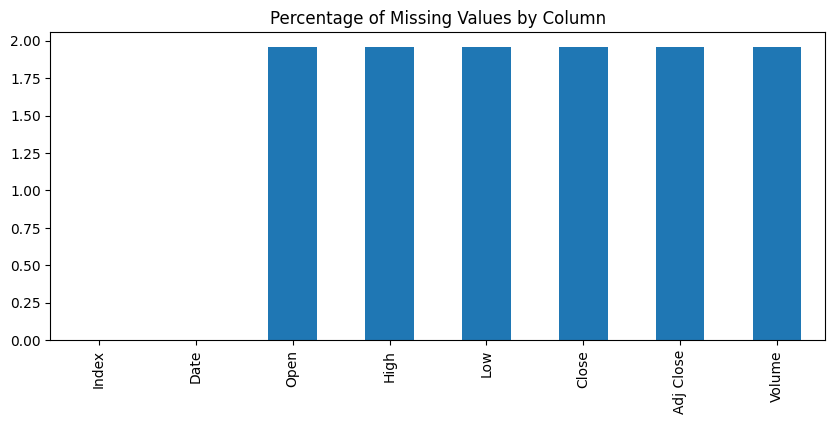

In [738]:
import matplotlib.pyplot as plt
(df_data.isnull().mean()*100).plot(kind="bar", figsize=(10,4))
plt.title("Percentage of Missing Values by Column")

Check the index

In [739]:
df_data.Index.unique()

array(['NYA', 'IXIC', 'HSI', '000001.SS', 'GSPTSE', '399001.SZ', 'NSEI',
       'GDAXI', 'KS11', 'SSMI', 'TWII', 'J203.JO', 'N225', 'N100'],
      dtype=object)

From the review we can see that df_data has the only missing values which also are only numeric columns & the df_processed came pre-cleaned of all the missing data issues. We will leave df_processed out of the steps going forward for the purpose of performing cleaning steps.

Next we'll check the size of the dataframe before the merge and then after to make sure we don't have any loss.

In [740]:
df_data.shape[0]

112457

In [741]:
df_events.shape[0]

1096

Join the df_data with df_info

In [742]:
df_data_combined = df_data.merge(df_info, how= 'left', on='Index')
df_data_combined.shape[0]

112457

# Clean up the Events Dataframe to Join with the data_combined Dataframe

In [743]:
df_events.columns

Index(['Sl. No', 'Name of Incident', 'Date', 'Month', 'Year', 'Country',
       'Type of Event', 'Place Name', 'Impact', 'Affected Population',
       'Important Person/Group Responsible', 'Outcome'],
      dtype='object')

In [744]:
# To properly join events with data_combined dataframe we'll need to create a data column to join on
# Step A: evaluate the Year, Month, & Date to see if anything needs cleaned before joining

In [745]:
for col in ['Year', 'Month', 'Date']:
    print(f"\nUnique {col} values:")
    print(df_events[col].unique())
    print("\nCounts:")
    print(df_events[col].value_counts(dropna=False))



Unique Year values:
['2600 BC' '1400 BC' '1206' '1526' '1858' '1947' '1971' '1998' '2008'
 '1498' '1757' '1857' '1905' '1960' '1984' '1999' '2005' '2012' '2022'
 '2020' '2018' '1951' '1962' '1974' '1975' '1991' '2001' '2009' '2019'
 '1983' '2013' '2014' '2007' '2016' '2015' '2017' '1885' '1919' '1920'
 '1922' '1930' '1942' '1943' '1950' '1935' '1969' '1980' '1988' '1653'
 '1585' '1956' '1940' '1972' '1997' '2006' '1986' '2010' '1990' '2004'
 '2002' '1948' '1945' '1977' '1987' '1978' '1931' '1967' '1982' '105' '0'
 '600' '618' '960' '1271' '1644' '1842' '1850' '1911' '1934' '1966' '150'
 '850' '1050' '650' '208' '1430' '1900' '1979' '1937' '1992' '220' '755'
 '1290' '1420' '1530' '1949' '1958' '1989' '882' '1237' '1380' '1490'
 '1598' '1730' '1917' '1938' '1941' '1918' '1921' '1929' '1928' '1939'
 '1953' '1957' '1968' '1993' '2000' '538' '645' '710' '794' '1030' '1185'
 '1274' '1336' '1467' '1543' '1568' '1603' '1635' '1868' '1894' '1904'
 '1912' '1853' '1871' '1877' '1910' '1964' '197

We can see that Date column which represent days have several non-day, missing, and unknown values that need to be cleaned before merging with the rest of the columns.
We also see that there are months that are showing as NANs as well, without the exact month dropping instead of assigning Jan or July would probably be safest.

In [746]:
# Normalize the text
df_events['Year_str'] = df_events['Year'].astype(str).str.upper().str.strip()
#Remove the BC
def parse_year(val):
    # BC case
    if 'BC' in val:
        num = ''.join([c for c in val if c.isdigit()])
        return -int(num) if num else None

    # AD or unknown case
    digits = ''.join([c for c in val if c.isdigit()])
    return int(digits) if len(digits) == 4 else None

# for all rows for years in string form apply parse_year function
df_events['Year_clean'] = df_events['Year_str'].apply(parse_year)

#Keep only modern events
df_events = df_events[df_events['Year_clean'] >= 1900]

In [747]:
# Function to clean the day (date) column
def clean_day(val):
    if not isinstance(val, str):
        return np.nan

    val = val.strip()

    if val.lower() in ['unknown', '', 'nan']:
        return np.nan

    if re.fullmatch(r'\d{4}', val):   # incorrectly placed year
        return np.nan

    match = re.search(r'\b([1-9]|[12][0-9]|3[01])\b', val)
    if match:
        return int(match.group(0))

    if re.fullmatch(r'[A-Za-z]+', val):  # month names in wrong column
        return np.nan

    return np.nan
df_events['Day_clean'] = df_events['Date'].apply(clean_day)
df_events['Day_clean'] = df_events['Day_clean'].fillna(1)

month_map = {
    'January':1, 'February':2, 'March':3, 'April':4,
    'May':5, 'June':6, 'July':7, 'August':8,
    'September':9, 'October':10, 'November':11, 'December':12
}

df_events['Month_num'] = df_events['Month'].map(month_map)

df_events = df_events.dropna(subset=['Month_num'])

df_events['Event_Date'] = pd.to_datetime(
    dict(
        year=df_events['Year_clean'],
        month=df_events['Month_num'],
        day=df_events['Day_clean']
    ), errors='coerce'
)

df_events['Event_Date_str'] = df_events['Event_Date'].dt.strftime('%Y-%m-%d')


In [748]:
for col in ['Year', 'Month', 'Date']:
    print(f"\nUnique {col} values:")
    print(df_events[col].unique())
    print("\nCounts:")
    print(df_events[col].value_counts(dropna=False))


Unique Year values:
['1947' '1971' '1998' '2008' '1905' '1984' '1999' '2005' '2012' '2022'
 '2020' '2018' '1951' '1962' '1974' '1975' '1991' '2001' '2009' '2019'
 '1983' '2013' '2014' '2007' '2016' '2015' '2017' '1919' '1920' '1922'
 '1930' '1942' '1950' '1935' '1969' '1980' '1988' '1956' '1960' '1940'
 '2006' '2010' '1990' '2002' '1948' '2004' '1972' '1987' '1978' '1911'
 '1997' '1949' '1989' '1917' '1941' '1945' '1918' '1921' '1939' '1943'
 '1953' '1957' '1968' '1979' '1986' '1993' '2000' '1931' '1937' '1910'
 '1964' '1970' '1995' '2011' '1901' '1915' '1932' '1992' '1973' '1967'
 '1996' '1994' '1961' '1954' '1976' '1946' '1938' '2003' '1959' '1963'
 '1965' '1958' '1985' '1929' '2021' '1903' '1914' '1982' '1926' '1936'
 '1928' '1944' '1966' '1952' '1981' '1977' '1933']

Counts:
Year
1960    22
2018    21
2019    20
2014    15
2020    14
        ..
1928     1
1952     1
1981     1
1977     1
1933     1
Name: count, Length: 107, dtype: int64

Unique Month values:
['August' 'December' '

Now with the df_events data columns cleaned

Here we will also filter for US Index

In [749]:
US_index_data = df_data_combined[df_data_combined['Region']=="United States"]

Since there are multiple events per date so a simple join on date wouldn't work well so we will take the following steps:
1. Create an event map of about 10 event groups
2. Map the groups to df_events['Type of Event']
3. Filter down to just US market index and events  
4. Combine the events on the same date into one row
5. Encode the grouped events into indicator features for clustering and modelling

In [750]:
# Step 1: Event map
event_type_map = {

    # Political
    'Political': 'political', 'Political Action': 'political',
    'Political Agreement': 'political', 'Political Change': 'political',
    'Political Corruption': 'political', 'Political Coup': 'political',
    'Political Crisis': 'political', 'Political Declaration': 'political',
    'Political Development': 'political', 'Political Movement': 'political',
    'Political Party': 'political', 'Political Party Formation': 'political',
    'Political Reform': 'political', 'Political Repression': 'political',
    'Political Revolution': 'political', 'Political Scandal': 'political',
    'Political Transition': 'political', 'Political Unification': 'political',
    'Political Union': 'political', 'Political Uprising': 'political',
    'Political/Economic Integration': 'political',
    'Political/Legal': 'political', 'Political/Secession': 'political',
    'Political/Territorial Change': 'political',
    'Legislation': 'political', 'Legislative': 'political',
    'General Election': 'political', 'General Elections': 'political',
    'Referendum': 'political', 'Election': 'political',
    'Declaration of Independence': 'political',
    'Independence Declaration': 'political',

    # Military
    'Military': 'military_conflict', 'Military Administration': 'military_conflict',
    'Military Aggression': 'military_conflict', 'Military Battle': 'military_conflict',
    'Military Campaign': 'military_conflict', 'Military Conflict': 'military_conflict',
    'Military Coup': 'military_conflict', 'Military Engagement': 'military_conflict',
    'Military Intervention': 'military_conflict', 'Military Invasion': 'military_conflict',
    'Military Occupation': 'military_conflict', 'Military Offensive': 'military_conflict',
    'Military Operation': 'military_conflict', 'Military Rebellion': 'military_conflict',
    'Military Siege': 'military_conflict', 'Military Surrender': 'military_conflict',
    'Military/Atomic Warfare': 'military_conflict',
    'Military/Political': 'military_conflict',
    'Military/Political Event': 'military_conflict',
    'Military/Political Incident': 'military_conflict',
    'War': 'military_conflict', 'War Declaration': 'military_conflict',
    'Regional Conflict': 'military_conflict', 'Civil War': 'military_conflict',
    'Rebellion': 'military_conflict', 'Revolution': 'military_conflict',
    'Coup': 'military_conflict', "Coup d'état": 'military_conflict',

    # Terrorism
    'Terrorism': 'terror', 'Domestic Terrorism': 'terror',

    # Disasters
    'Natural Disaster': 'disaster', 'Natural Event': 'disaster',
    'Industrial Disaster': 'disaster', 'Industrial Accident': 'disaster',
    'Nuclear Accident': 'disaster', 'Space Exploration Disaster': 'disaster',
    'Aviation': 'disaster', 'Accident': 'disaster',
    'Maritime Disaster': 'disaster',

    # Economic
    'Economic': 'economic', 'Economic Crisis': 'economic',
    'Economic Development': 'economic', 'Economic Integration': 'economic',
    'Economic Reform': 'economic', 'Economic Policy': 'economic',
    'Central Banking Institution': 'economic',
    'International Economic Agreement': 'economic',
    'International Economic Integration': 'economic',
    'International Trade Membership': 'economic',
    'Financial Technology': 'economic',

    # Diplomacy & Treaties
    'Diplomatic': 'diplomacy', 'Diplomatic Agreement': 'diplomacy',
    'Diplomatic Event': 'diplomacy', 'Diplomatic Incident': 'diplomacy',
    'Diplomatic Meeting': 'diplomacy', 'Diplomatic Statement': 'diplomacy',
    'International Agreement': 'diplomacy', 'International Cooperation': 'diplomacy',
    'International Organization': 'diplomacy', 'International Treaty': 'diplomacy',
    'Peace Agreement': 'diplomacy', 'Peace Process': 'diplomacy',
    'Treaty': 'diplomacy', 'Negotiation': 'diplomacy',

    # Social Movements / Unrest
    'Social Movement': 'social_movement', 'Social Unrest': 'social_movement',
    'Civil Disobedience': 'social_movement',
    'Civil Disobedience Movement': 'social_movement',
    'Civil Rights': 'social_movement', 'Civil Unrest': 'social_movement',
    'Mass Protest': 'social_movement', 'Protest Movement': 'social_movement',
    'Protests': 'social_movement', 'Democratic Uprising': 'social_movement',
    'Violent Protest': 'social_movement',

    # Crime / Violence
    'Criminal Incident': 'crime_violence', 'Massacre': 'crime_violence',
    'Gun Violence': 'crime_violence', 'Genocide': 'crime_violence',

    # Science & Technology
    'Scientific': 'science_tech', 'Technology': 'science_tech',
    'Technological Advancement': 'science_tech',
    'Space Exploration': 'science_tech', 'Space Agency': 'science_tech',
    'Engineering Achievement': 'science_tech', 'Medical': 'science_tech',

    # Infrastructure
    'Infrastructure': 'infrastructure', 'Urban Development': 'infrastructure',
    'Telecommunications': 'infrastructure', 'Rail': 'infrastructure',

    # Cultural
    'Cultural': 'cultural', 'Cultural Celebration': 'cultural',
    'Cultural Change': 'cultural', 'Cultural Infrastructure': 'cultural',
    'Commemoration': 'cultural', 'World Expo': 'cultural',
    "World's Fair": 'cultural',

    # Environmental
    'Environmental': 'environmental', 'Environmental/Economic Policy': 'environmental',
    'Environmental/Social': 'environmental',
    'Wildlife Conservation': 'environmental',

    # Health
    'Health': 'health', 'Public Health': 'health',

    # Geopolitics / Sovereignty
    'Annexation': 'sovereignty_geopolitical', 'Country Formation': 'sovereignty_geopolitical',
    'State Establishment': 'sovereignty_geopolitical', 'State Formation': 'sovereignty_geopolitical',
    'Union': 'sovereignty_geopolitical', 'Independence': 'sovereignty_geopolitical',
    'Partition': 'sovereignty_geopolitical', 'Sovereignty Transition': 'sovereignty_geopolitical',

    # Sports
    'Sport': 'sport', 'Sports': 'sport',
    'Sporting Event': 'sport', 'International Sports Event': 'sport',

    # Everything else
    'Administrative': 'other', 'Historical': 'other', 'Monument': 'other',
    'Media': 'other', 'Era Change': 'other'
}


In [751]:
# Step 2: create a mapping function to map the groups to df_events
def map_event_type(event):
    if pd.isna(event):
        return 'other'
    return event_type_map.get(event, 'other')
df_events['Event_Type_Mapped'] = df_events['Type of Event'].apply(map_event_type)


In [752]:
# verify mapping worked
df_events['Event_Type_Mapped'].value_counts()

,count
Event_Type_Mapped,
political,125
other,115
military_conflict,80
sovereignty_geopolitical,55
disaster,34
diplomacy,31
economic,24
social_movement,20
sport,18


In [753]:
# Step 3: Filter events for US + globally relevant categories

core_relevant = [
    'military_conflict',
    'terror',
    'economic',
    'political',
    'sovereignty_geopolitical',
    'diplomacy'
]

# US events but only if they are one of the core relevant types
df_us = df_events[
    (df_events['Country'] == 'United States') &
    (df_events['Event_Type_Mapped'].isin(core_relevant))
]

# Global events: same rule
df_global = df_events[
    df_events['Event_Type_Mapped'].isin(core_relevant)
]

# Combine
df_events_filtered = pd.concat([df_us, df_global]).drop_duplicates()




In [754]:
# 4: Combine them into one row per date
df_events_grouped = (
    df_events_filtered
    .groupby('Event_Date')
    .agg({
        'Event_Type_Mapped': list,
        'Outcome': list,
        'Impact': list
    })
    .reset_index()
)


In [755]:
df_events_grouped.head()

,Event_Date,Event_Type_Mapped,Outcome,Impact
0,1901-01-01,[political],[Positive],[Unified the six separate British colonies int...
1,1905-06-07,[sovereignty_geopolitical],[Positive],[Dissolution of the union with Sweden]
2,1910-08-22,"[diplomacy, sovereignty_geopolitical]","[Negative, Negative]","[Officially annexed Korea, making it a part of..."
3,1910-11-20,[military_conflict],[Positive],[Major revolution that transformed Mexican pol...
4,1911-10-10,[political],[Positive],"[Overthrew the Qing Dynasty, leading to the es..."


In [756]:
#5: Create dummy features to encode before merging to df_combined

# 5a. Extract the event types
all_event_types = sorted(
    set().union(*df_events_grouped['Event_Type_Mapped'])
)
all_event_types



['diplomacy',
 'economic',
 'military_conflict',
 'political',
 'sovereignty_geopolitical',
 'terror']

In [757]:
# 5b.
for event_type in all_event_types:
    df_events_grouped[f"event_{event_type}"] = df_events_grouped['Event_Type_Mapped'].apply(
        lambda x: 1 if event_type in x else 0
    )
df_events_grouped.head()


,Event_Date,Event_Type_Mapped,Outcome,Impact,event_diplomacy,event_economic,event_military_conflict,event_political,event_sovereignty_geopolitical,event_terror
0,1901-01-01,[political],[Positive],[Unified the six separate British colonies int...,0,0,0,1,0,0
1,1905-06-07,[sovereignty_geopolitical],[Positive],[Dissolution of the union with Sweden],0,0,0,0,1,0
2,1910-08-22,"[diplomacy, sovereignty_geopolitical]","[Negative, Negative]","[Officially annexed Korea, making it a part of...",1,0,0,0,1,0
3,1910-11-20,[military_conflict],[Positive],[Major revolution that transformed Mexican pol...,0,0,1,0,0,0
4,1911-10-10,[political],[Positive],"[Overthrew the Qing Dynasty, leading to the es...",0,0,0,1,0,0


Now that the dates are down to one row and encoded we'll join the event_df with the US_index_data

In [758]:
# Ensure both are datetime
US_index_data['Date'] = pd.to_datetime(US_index_data['Date'])
df_events_grouped['Event_Date'] = pd.to_datetime(df_events_grouped['Event_Date'])

/tmp/ipython-input-2216507591.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  US_index_data['Date'] = pd.to_datetime(US_index_data['Date'])


In [759]:
US_index_data.shape[0]

26638

In [760]:
df_data_index = US_index_data.merge(
    df_events_grouped.drop(columns=['Event_Type_Mapped', 'Outcome', 'Impact']),
    how='left',
    left_on='Date',
    right_on='Event_Date'
    )

In [761]:
df_data_index.shape[0]

26638

Check duplicates

In [762]:
df_data_index.duplicated().sum()
# none exist

np.int64(0)

Next we'll check all the data types for feature correlation

In [763]:
# numeric columns
print('All columns: ', df_data_index.columns,'\n')

print('Numeric columns: ', df_data_index.select_dtypes(include="number").columns)

All columns:  Index(['Index', 'Date', 'Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'Region', 'Exchange', 'Currency', 'Event_Date', 'event_diplomacy',
       'event_economic', 'event_military_conflict', 'event_political',
       'event_sovereignty_geopolitical', 'event_terror'],
      dtype='object') 

Numeric columns:  Index(['Open', 'High', 'Low', 'Close', 'Adj Close', 'Volume',
       'event_diplomacy', 'event_economic', 'event_military_conflict',
       'event_political', 'event_sovereignty_geopolitical', 'event_terror'],
      dtype='object')


Check each numeric variable's distribution for skew, outiers or dominant categories

In [764]:
df_data_index.select_dtypes(include="number").describe()

,Open,High,Low,Close,Adj Close,Volume,event_diplomacy,event_economic,event_military_conflict,event_political,event_sovereignty_geopolitical,event_terror
count,26637.000000,26637.000000,26637.000000,26637.000000,26637.000000,2.663700e+04,260.000000,260.000000,260.000000,260.000000,260.000000,260.000000
mean,3276.605549,3291.427464,3259.971029,3276.755938,3276.755938,1.108833e+09,0.115385,0.092308,0.192308,0.419231,0.103846,0.115385
std,3629.002232,3646.806561,3609.262895,3629.405774,3629.405774,1.537763e+09,0.320102,0.290018,0.394874,0.494385,0.305649,0.320102
min,54.869999,54.869999,54.869999,54.869999,54.869999,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,547.510010,547.609985,547.080017,547.510010,547.510010,0.000000e+00,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,1804.939941,1811.599976,1789.719971,1803.880005,1803.880005,1.307000e+08,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,5428.979980,5460.910156,5398.950195,5429.080078,5429.080078,1.918690e+09,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000
max,16590.429690,16685.890630,16531.949220,16590.429690,16590.429690,1.145623e+10,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [765]:
df_data_index

,Index,Date,Open,High,Low,Close,Adj Close,Volume,Region,Exchange,Currency,Event_Date,event_diplomacy,event_economic,event_military_conflict,event_political,event_sovereignty_geopolitical,event_terror
0,NYA,1965-12-31,528.690002,528.690002,528.690002,528.690002,528.690002,0.000000e+00,United States,New York Stock Exchange,USD,NaT,NaN,NaN,NaN,NaN,NaN,NaN
1,NYA,1966-01-03,527.210022,527.210022,527.210022,527.210022,527.210022,0.000000e+00,United States,New York Stock Exchange,USD,NaT,NaN,NaN,NaN,NaN,NaN,NaN
2,NYA,1966-01-04,527.840027,527.840027,527.840027,527.840027,527.840027,0.000000e+00,United States,New York Stock Exchange,USD,NaT,NaN,NaN,NaN,NaN,NaN,NaN
3,NYA,1966-01-05,531.119995,531.119995,531.119995,531.119995,531.119995,0.000000e+00,United States,New York Stock Exchange,USD,NaT,NaN,NaN,NaN,NaN,NaN,NaN
4,NYA,1966-01-06,532.070007,532.070007,532.070007,532.070007,532.070007,0.000000e+00,United States,New York Stock Exchange,USD,NaT,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
26633,IXIC,2021-05-24,13557.209960,13708.849610,13551.009770,13661.169920,13661.169920,3.490650e+09,United States,NASDAQ,USD,NaT,NaN,NaN,NaN,NaN,NaN,NaN
26634,IXIC,2021-05-25,13721.540040,13751.139650,13631.799810,13657.169920,13657.169920,4.084480e+09,United States,NASDAQ,USD,NaT,NaN,NaN,NaN,NaN,NaN,NaN
26635,IXIC,2021-05-26,13693.940430,13750.160160,13679.589840,13738.000000,13738.000000,4.231140e+09,United States,NASDAQ,USD,NaT,NaN,NaN,NaN,NaN,NaN,NaN
26636,IXIC,2021-05-27,13742.589840,13776.519530,13701.629880,13736.280270,13736.280270,5.057550e+09,United States,NASDAQ,USD,NaT,NaN,NaN,NaN,NaN,NaN,NaN


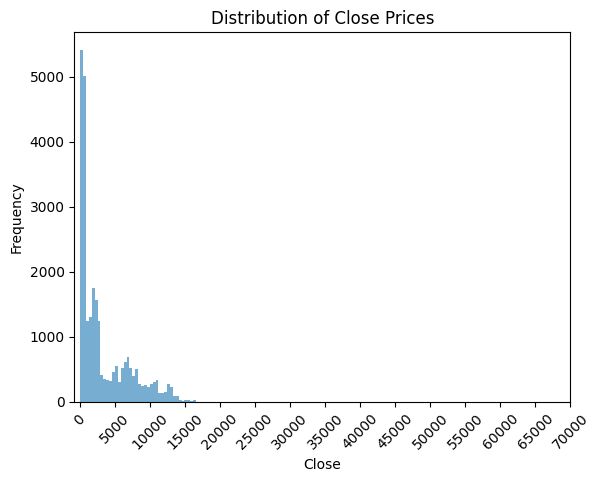

In [766]:
# Open high, low, close, adj close are fairly similar so will just plot 1
# create two histograms to evaluate the layout of the data
plt.hist(df_data_index['Close'], bins=40, alpha=0.6)
plt.title('Distribution of Close Prices')
plt.xlabel("Close")
plt.ylabel("Frequency")
plt.xticks(
    ticks=range(0, 70001,5000),
           rotation=45
)
plt.show()

Here we see a large right skew with most of the data clusters in the lower price range (0–1,000). This tells us that the indices we are reviewing all have different price scales.

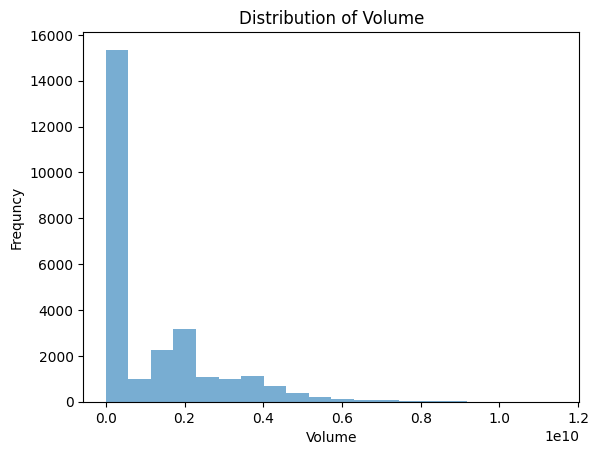

In [767]:
# Volume has unique values so will plot it
plt.hist(df_data_index["Volume"],bins=20,alpha=0.6)
plt.title("Distribution of Volume")
plt.xlabel("Volume")
plt.ylabel("Frequncy")
# plt.xticks(
#     ticks=range(0,8,2),
#     rotation=45
# )
plt.show()


Right-skew means 90% of the data is crammed into one tiny corner

A giant spike near zero with a long tail of massive values and no real middle range.For a model, that’s like trying to read a book where:

90% of the words are “the”

10% are random Latin

Nothing in between makes patterns

The model can’t learn clean structure.
So we introduce log to capture orders of magnitude.

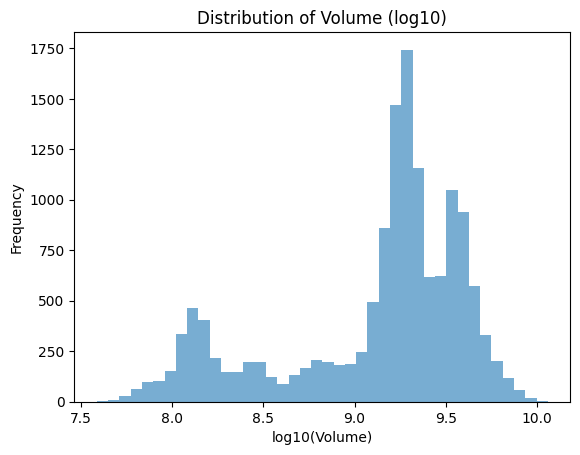

In [768]:
# since we see a large right skew we'll use log to trasform the data

plt.hist(
    df_data_index['Volume'][df_data_index['Volume'] > 0].apply(np.log10),
    bins=40, alpha=0.6
)

plt.title("Distribution of Volume (log10)")
plt.xlabel("log10(Volume)")
plt.ylabel("Frequency")
plt.show()

This works much better to show the distribution of the trade volumes.
After log-transforming volume, we see a clean, bell-shaped concentration between log10 8.5–9.5, meaning most trading days had between 300 million and 3 billion shares traded. This tells us volume is stable on a log scale and suitable for modeling, unlike the raw skewed distribution.

Numeric vs. Categorical Analysis

In [769]:
numeric_columns = df_data_index.select_dtypes(include=["number"]).columns
categorical_columns = df_data_index.select_dtypes(exclude=["number"]).columns

In [770]:
categorical_columns

Index(['Index', 'Date', 'Region', 'Exchange', 'Currency', 'Event_Date'], dtype='object')

/tmp/ipython-input-644840560.py:1: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_data_index['Daily_Return'] = df_data_index.groupby('Index')['Close'].pct_change()


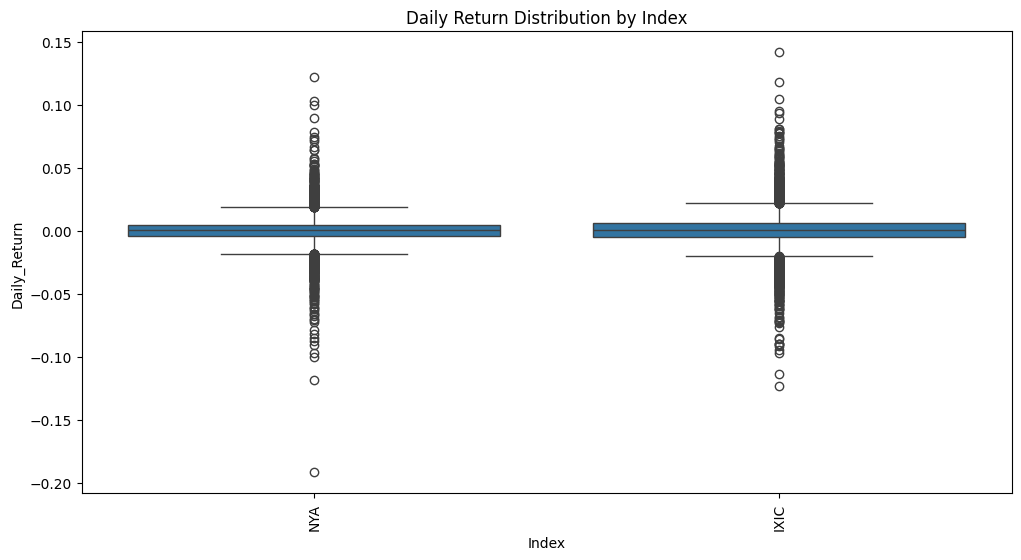

/usr/local/lib/python3.12/dist-packages/pandas/core/arraylike.py:399: RuntimeWarning: divide by zero encountered in log10
  result = getattr(ufunc, method)(*inputs, **kwargs)


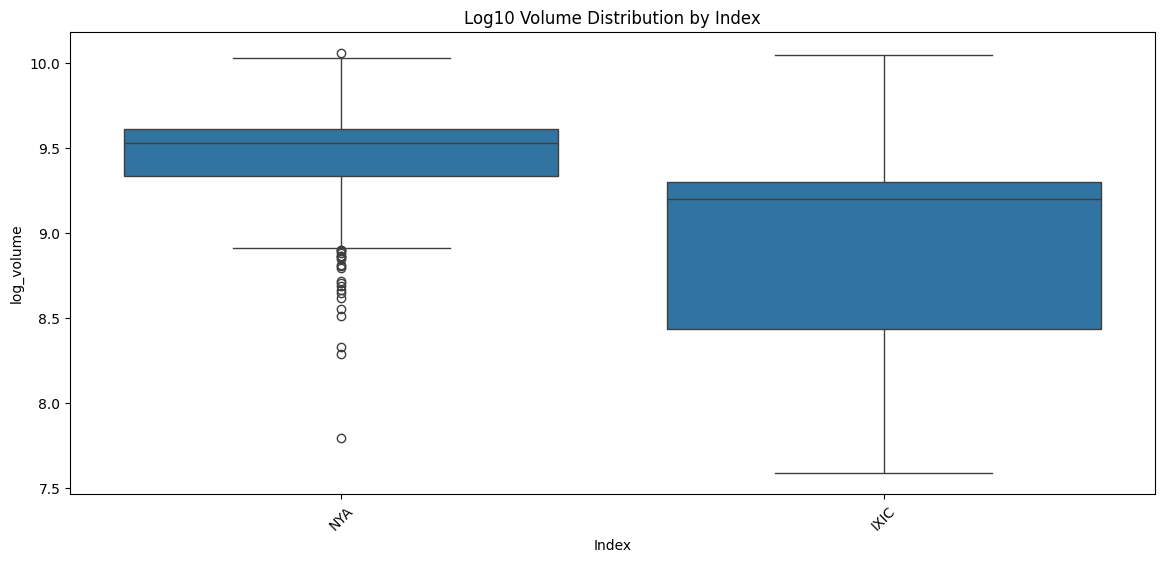

'\nAfter converting volume to a log scale, GSPTSE has the widest box in the plot (around log10 values 7–10). That means its daily trading volume swings a lot —\nfrom about 10 million shares on some days to over 10 billion on others. This shows big changes in how much the market trades, not big swings in the index’s price.\n'

In [771]:
df_data_index['Daily_Return'] = df_data_index.groupby('Index')['Close'].pct_change()

plt.figure(figsize=(12,6))
sns.boxplot(x='Index', y='Daily_Return', data=df_data_index)
plt.xticks(rotation=90)
plt.title("Daily Return Distribution by Index")
plt.show()
'''NOTE:
Indexes with a wide IQR (interquartile range) are riskier. Indexes with a tight IQR are steadier.
The typical daily return is close to zero, but the indices differ heavily in volatility. HSI, TWII, and 399001.SZ show larger day-to-day swings, while N100 and GDAXI are comparatively stable.
'''
df_data_index['log_volume'] = np.log10(df_data_index['Volume'])

plt.figure(figsize=(14,6))
sns.boxplot(x='Index', y='log_volume', data=df_data_index)
plt.xticks(rotation=45)
plt.title("Log10 Volume Distribution by Index")
plt.show()

'''
After converting volume to a log scale, GSPTSE has the widest box in the plot (around log10 values 7–10). That means its daily trading volume swings a lot —
from about 10 million shares on some days to over 10 billion on others. This shows big changes in how much the market trades, not big swings in the index’s price.
'''

Price variables all move together (corr ≈ 1.0), so they’re redundant. Volume barely correlates with price (≈ 0.14). To get more insight, we need to examine distribution patterns by index or create additional features like daily returns or volatility.

In [772]:
df_data_index.head()

,Index,Date,Open,High,Low,Close,Adj Close,Volume,Region,Exchange,Currency,Event_Date,event_diplomacy,event_economic,event_military_conflict,event_political,event_sovereignty_geopolitical,event_terror,Daily_Return,log_volume
0,NYA,1965-12-31,528.690002,528.690002,528.690002,528.690002,528.690002,0.0,United States,New York Stock Exchange,USD,NaT,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-inf
1,NYA,1966-01-03,527.210022,527.210022,527.210022,527.210022,527.210022,0.0,United States,New York Stock Exchange,USD,NaT,NaN,NaN,NaN,NaN,NaN,NaN,-0.002799,-inf
2,NYA,1966-01-04,527.840027,527.840027,527.840027,527.840027,527.840027,0.0,United States,New York Stock Exchange,USD,NaT,NaN,NaN,NaN,NaN,NaN,NaN,0.001195,-inf
3,NYA,1966-01-05,531.119995,531.119995,531.119995,531.119995,531.119995,0.0,United States,New York Stock Exchange,USD,NaT,NaN,NaN,NaN,NaN,NaN,NaN,0.006214,-inf
4,NYA,1966-01-06,532.070007,532.070007,532.070007,532.070007,532.070007,0.0,United States,New York Stock Exchange,USD,NaT,NaN,NaN,NaN,NaN,NaN,NaN,0.001789,-inf


### Feature Engineering

In [773]:
# Adding in more features
# Volatility_5D = std of last 5 daily returns
df_data_index['Volatility_5D'] = (df_data_index.groupby('Index')['Daily_Return'].rolling(window=5).std().reset_index(level=0, drop=True))

# Volatility_10D
df_data_index['Volatility_10D'] = (df_data_index.groupby('Index')['Daily_Return'].rolling(window=10).std().reset_index(level=0, drop=True))

# Combined the Rolling_Avg_Close_50D with Trend Distance (how far above / below trend is the market
df_data_index['Rolling_Avg_Close_50D'] = (df_data_index.groupby('Index')['Close'].rolling(window=50).mean().reset_index(level=0, drop=True))
df_data_index['Trend_Dist_50D'] = df_data_index['Close'] / df_data_index['Rolling_Avg_Close_50D'] - 1

# Combined the Rolling_Avg_Close_200D with Trend Distance (how far above / below trend is the market
df_data_index['Rolling_Avg_Close_200D'] = (df_data_index.groupby('Index')['Close'].rolling(window=200).mean().reset_index(level=0, drop=True))
df_data_index['Trend_Dist_200D'] = df_data_index['Close'] / df_data_index['Rolling_Avg_Close_200D'] - 1


# Volume_Change (pct change) in market activity
df_data_index['Volume_Change'] = (df_data_index.groupby('Index')['Volume'].pct_change())

# Range = High − Low (shows a raw measure how volatile the day was)
df_data_index['Range'] =  df_data_index['High'] - df_data_index['Low']

# Intraday_Volatility = (High − Low) / Open (shows a standardized measure how volatile the day was by opening price in a single day)
df_data_index['Intraday_Volatility'] =  (df_data_index['High'] - df_data_index['Low']) / (df_data_index['Open'])

# RSI

# Momentum Indicator

# Prediction value = Profit



/tmp/ipython-input-233214672.py:18: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_data_index['Volume_Change'] = (df_data_index.groupby('Index')['Volume'].pct_change())


Here we will also add in a target Event_Return_5D not as a feature but something to predict.

/tmp/ipython-input-1321982734.py:5: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  returns = df_data_index['Close'].pct_change()
/tmp/ipython-input-1321982734.py:19: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_data_index['Event_Return_1D'] = df_data_index['Close'].pct_change().shift(-1)
/tmp/ipython-input-1321982734.py:20: FutureWarning: The default fill_method='pad' in Series.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  df_data_index['Event_Return_

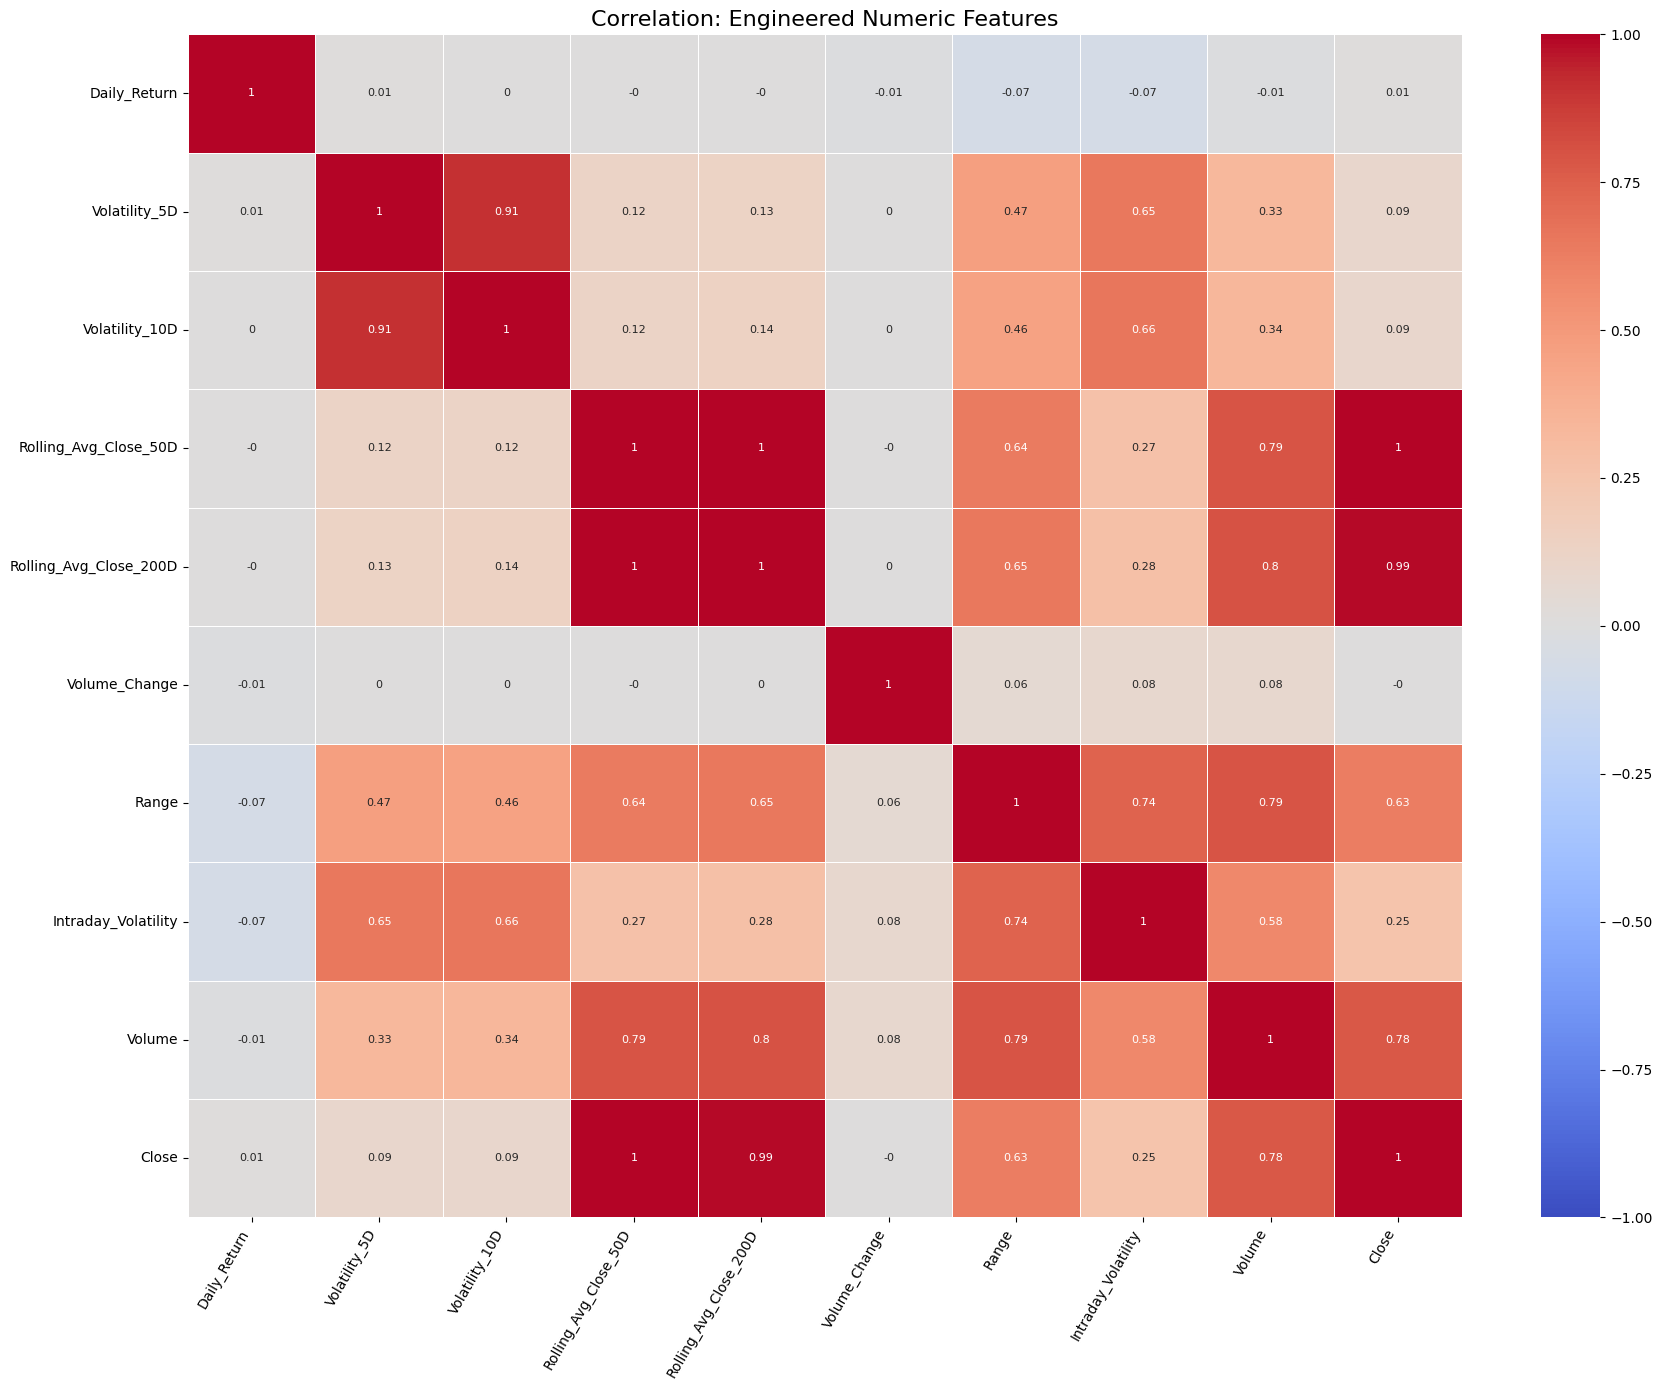

In [774]:
# 1) Sort by date just to be safe
df_data_index = df_data_index.sort_values("Date")

# 2) Event-period volatility
returns = df_data_index['Close'].pct_change()

# check the new features
engineered_features = [
    'Daily_Return', 'Volatility_5D', 'Volatility_10D',
    'Rolling_Avg_Close_50D', 'Rolling_Avg_Close_200D',
    'Volume_Change', 'Range', 'Intraday_Volatility'
]

other_features = ['Volume', 'Close'
]

# Add forward return for the model target

df_data_index['Event_Return_1D'] = df_data_index['Close'].pct_change().shift(-1)
df_data_index['Event_Return_5D'] = df_data_index['Close'].pct_change(5).shift(-5)
# df_data_index['Event_Return_30D'] = df_data_index['Close'].pct_change(30).shift(-30)
# df_data_index['Event_Vol_5D']  = returns.shift(-1).rolling(5).std()
# df_data_index['Event_Vol_10D'] = returns.shift(-1).rolling(10).std()

# reaction_features = [
#     'Event_Return_1D', 'Event_Return_5D', 'Event_Return_30D',
#     'Event_Vol_5D', 'Event_Vol_10D'
# ]

# Combine into one flat list
all_features = engineered_features + other_features

corr_matrix = df_data_index[all_features].corr()

corr_matrix_rounded = corr_matrix.round(2)

plt.figure(figsize=(18, 14))  # adjust size here

sns.heatmap(
    corr_matrix_rounded,
    annot=True,
    cmap='coolwarm',
    vmin=-1,
    vmax=1,
    annot_kws={"size": 8},   # smaller numbers so they fit
    linewidths=0.5
)

plt.title("Correlation: Engineered Numeric Features", fontsize=16)
plt.xticks(rotation=60, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()



The correlation heatmap is basically a redundancy detector (which features to drop).
High correlations indicate features we should drop (especially for linear models) like below:
- Volatility_5D <--> Volatility_10D
- Rolling_Avg_Close_50D <--> Rolling_Avg_Close_200D
- Close <--> all moving averages

But low correlation does not imply usefulness — feature importance from the model determines that.
So correlation is mainly for removing duplicates, not selecting predictors.

Next Steps:
1. Clean the data using any non-leakage methods (avoiding mean, mode etc)
2. Split the data
3. Clean the split data (if necessary)
4. Run regression models

Step 1. a. Check for zero counts

In [775]:
df_data_index.isna().sum()

,0
Index,0
Date,0
Open,1
High,1
Low,1
Close,1
Adj Close,1
Volume,1
Region,0
Exchange,0


Step 1. b. Run non leak cleaning.
- event_ columns can be filled with zero since that just means there was no date from the event dataframe matching a date on the index dataframe.

In [776]:
# Non leak cleaning
# 1. Drop unused columns
df_data_index = df_data_index.drop(columns=["Event_Date"])

# 2. Fill event columns with 0
event_cols = [c for c in df_data_index.columns if c.startswith("event_")]
df_data_index[event_cols] = df_data_index[event_cols].fillna(0)

# 3. Fix volume-related issues
df_data_index['log_volume'] = np.log1p(df_data_index['Volume'])
df_data_index['Volume_Change'] = (
    df_data_index.groupby('Index')['Volume']
    .pct_change()
    .fillna(0)
)
df_data_index = df_data_index.drop(columns=["Index"])

# 4. Keep engineered features WITH missing values (don’t drop them yet)
#    We will handle NaNs separately for train/test
# save which columns were window-based
window_cols = [
    'Trend_Dist_50D',
    'Trend_Dist_200D',
    'Volatility_5D','Volatility_10D',
    'log_volume','Volume_Change','Range','Intraday_Volatility'
]

/tmp/ipython-input-436325423.py:13: FutureWarning: The default fill_method='ffill' in SeriesGroupBy.pct_change is deprecated and will be removed in a future version. Either fill in any non-leading NA values prior to calling pct_change or specify 'fill_method=None' to not fill NA values.
  .pct_change()


In [777]:
# Final safety cleaning BEFORE selecting features
df_data_index = df_data_index.replace([np.inf, -np.inf], np.nan)

# Some engineered features can still produce NaN's; fill with 0 for baseline model
# df_data_index = df_data_index.fillna(0) # remove since we need to only fill zeros on the right features


# Select numeric-only columns
numeric_cols = df_data_index.select_dtypes(include=['float64', 'int64']).columns.tolist()

# remove prices since that is redundant
drop_prices = ["Open", "High", "Low", "Close", "Adj Close"]
numeric_cols = [c for c in numeric_cols if c not in drop_prices]

# remove the target 'Event_Return_5D' from the feature list.
# Note: we also added the rolling averages since they were overbearing in the features later
for col in ['Event_Return_5D', 'Event_Return_1D','Cluster', 'Rolling_Avg_Close_50D', 'Rolling_Avg_Close_200D']:
    if col in numeric_cols:
        numeric_cols.remove(col)


df_model = df_data_index.copy()
#df_model = df_data_index[feature_cols + [target]].dropna()
# X = df_model[feature_cols]
# y = df_model[target]
X = df_model[numeric_cols]
y = df_model['Event_Return_5D']

Step 2. Split the data

In [778]:
# 1. Split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, shuffle=False
)

# 2. Drop NaNs from train
X_train = X_train.dropna()
y_train = y_train.loc[X_train.index]

# 3. DROP NaNs from test TARGET ONLY
# the 'Event_Return_5D' calculates 5 days into the future so the first 5 days of the timeseries will be missing missing data
# we drop them after the split to avoid removing helpful data
valid_test_idx = y_test.dropna().index

y_test = y_test.loc[valid_test_idx]
X_test = X_test.loc[valid_test_idx]

# 4. Fill window features on test ONLY
X_test[window_cols] = X_test[window_cols].fillna(0)


Now that the data is cleaned we'll start with Linear Regression

In [779]:
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

lr = LinearRegression()
lr.fit(X_train, y_train)

preds = lr.predict(X_test)

print("LR RMSE:", np.sqrt(mean_squared_error(y_test, preds)))
print("LR R2:", r2_score(y_test, preds))


LR RMSE: 0.67714064607237
LR R2: 0.03679268589213258


Linear regression is the baseline sanity check. It assumes a straight-line relationship between engineered features and returns, which the market almost never follows. A 0.31 R² actually means our features do contain signal, but LR can’t exploit it. Next step is tree-based models which capture nonlinear structure.

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score
# mdoel
rf = RandomForestRegressor(
    n_estimators=300,
    max_depth=None,
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)
rf.fit(X_train, y_train)

#predictions
rf_preds = rf.predict(X_test)

# Metrics
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_preds))
rf_r2 = r2_score(y_test, rf_preds)

print("Random Forest RMSE:", rf_rmse)
print("Random Forest R2:", rf_r2)


In [ ]:
# Feature importance visualization
importances = rf.feature_importances_
feat_names = X_train.columns

# Put into a DataFrame for readability
imp_df = pd.DataFrame({
    'feature': feat_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(imp_df['feature'].head(15), imp_df['importance'].head(15))
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (Random Forest)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

imp_df.head(20)


We'll try XGboost yet

In [ ]:
from xgboost import XGBRegressor

xgb = XGBRegressor(
    n_estimators=400,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.9,
    colsample_bytree=0.8,
    objective='reg:squarederror',
    random_state=42
)

xgb.fit(X_train, y_train)

from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

preds = xgb.predict(X_test)

rmse = np.sqrt(mean_squared_error(y_test, preds))
r2 = r2_score(y_test, preds)

print("XGBoost RMSE:", rmse)
print("XGBoost R2:", r2)


In [ ]:
# Feature importance visualization
importances = xgb.feature_importances_
feat_names = X_train.columns

# Put into a DataFrame for readability
imp_df = pd.DataFrame({
    'feature': feat_names,
    'importance': importances
}).sort_values('importance', ascending=False)

# Plot
plt.figure(figsize=(10, 6))
plt.barh(imp_df['feature'].head(15), imp_df['importance'].head(15))
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (XGBoost)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

imp_df.head(20)


Even with the XGBoost model we weren't seeing great model performance so we attempted a final switch adjusting for a classification.

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

future_cols = [
    "Event_Return_1D",
    "Event_Return_5D",
    "Event_Return_30D",
    "Event_Vol_5D",
    "Event_Vol_10D"
]

X = X.drop(columns=future_cols, errors='ignore')




# New target: up vs down 5-day return
#df_model['Event_Up_5D'] = (df_model['Event_Return_5D'] > 0).astype(int)
# Changing out the variable to 1d after the event to reduce the noise
df_model['Up_1D'] = (df_model['Event_Return_1D'] > 0).astype(int)
y_clf = df_model['Up_1D']

X_clean = X.drop(columns=future_cols, errors='ignore')

X_train_c, X_test_c, y_train_c, y_test_c = train_test_split(
    X_clean, y_clf, test_size=0.2, shuffle=False
)


# Random Forest classifier
rf_clf = RandomForestClassifier(
    n_estimators=300,
    max_depth=None,
    class_weight='balanced',
    min_samples_split=5,
    min_samples_leaf=3,
    random_state=42,
    n_jobs=-1
)

rf_clf.fit(X_train_c, y_train_c)
rf_probs = rf_clf.predict_proba(X_test_c)[:, 1]
rf_preds_class = (rf_probs >= 0.5).astype(int)

rf_acc = accuracy_score(y_test_c, rf_preds_class)
rf_auc = roc_auc_score(y_test_c, rf_probs)

print("RF Classifier Accuracy:", rf_acc)
print("RF Classifier ROC-AUC:", rf_auc)
print("Confusion matrix:\n", confusion_matrix(y_test_c, rf_preds_class))


So this peforms significantly better than the regression models

In [ ]:
importances_clf = rf_clf.feature_importances_
feat_names = X_train_c.columns

imp_df_clf = pd.DataFrame({
    'feature': feat_names,
    'importance': importances_clf
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(imp_df_clf['feature'].head(15), imp_df_clf['importance'].head(15))
plt.gca().invert_yaxis()
plt.title("Top 15 Feature Importances (RF Classifier)")
plt.xlabel("Importance Score")
plt.tight_layout()
plt.show()

imp_df_clf.head(20)


## Step 3:  Identify 1-3 research questions and perform analysis

Now that you have a better understanding of the data, you will want to form a research question which is interesting to you. The research question should be broad enough to be of interest to a reader but narrow enough that the question can be answered with the data.  Some examples:

* __Too Narrow:__  What is the GDP of the U.S. for 2011?  This is just asking for a fact or a single data point.  

* __Too Broad:__  What is the primary reason for global poverty?  This could be a Ph.D. thesis and would still be way too broad.  What data will you use to answer this question?  Even if a single dataset offered an answer, would it be defendable given the variety of datasets out there?

* __Good:__  Can you use simple sentiment analysis on comments about movies in a movie database to predict its box office earnings?  If you have, or can obtain, data on a variety of movies and you have their box office earnings, this is a question which you can potentially answer well.

__Remember__, this course is for learning Python. You will not be graded on the complexity, accuracy or performance of your analytical methods. However, you are expected to use a Python library, e.g., _scikitlearn_, successfully to generate results and explain why you picked the methods you used.


The Questions:
1. Can we quanitfy how global events relate to market moves?
2. Can we predict 5-day market returns using event + market features?

In [ ]:
#OVERVIEW YOUR QUESTION AND PERFORM YOUR ANALYSIS IN THIS SECTION

## Step 4:  Present your findings

In this step, you can begin to report your findings.  What did you learn from the data and how do your findings help answer your research question?  Use _matplotlib_ visualizations to present these findings.


__Remember:__ Rarely will a single data analysis conclusively answer a research question.  Here, you need to identify possible limitations.  For example, are your results limited to a certain area, city, or country?  Are you making assumptions about the data which may, or may not, be valid (e.g., that students in one term are equally qualified as students in another)?  Document these limitations in a few paragraphs.


In [ ]:
#EXPAND THIS SECTION TO PRESENT YOUR FINDINGS